## <span style="color:#1f497d; border-bottom: 2px solid #1f497d; padding-bottom: 5px;">Ejercicio 3: Inspección visual de un producto</span>

### <span style="color:#c0504d;">Ficha PEAS</span>

* <b style="color:#4f81bd;">Percepción (S):</b> Imagen de 5x5 píxeles en forma de matriz binaria (0 = normal, 1 = defectuoso).
* <b style="color:#4f81bd;">Acciones (A):</b> Aprobar producto, Enviar a revisión manual, Rechazar producto.
* <b style="color:#4f81bd;">Entorno (E):</b> Línea de producción automatizada (cinta transportadora, sistema de iluminación, cámara).
* <b style="color:#4f81bd;">Objetivo:</b> Filtrar productos defectuosos de manera precisa para asegurar la calidad de entrega y minimizar desperdicios.
* <b style="color:#4f81bd;">Medida de desempeño (P):</b> Porcentaje de productos defectuosos bloqueados correctamente, minimización de falsos positivos, velocidad de inspección en la línea.

### <span style="color:#c0504d;">Justificación de las reglas</span>

<span style="color:#595959;">Las reglas equilibran la calidad y el costo operativo. Un producto sin ningún defecto (0 píxeles) se aprueba directamente. Si presenta una cantidad mínima de anomalías (1 a 3 píxeles), se envía a revisión manual para que un humano confirme si es un error de lectura de la cámara (polvo, reflejo) o un daño superficial real. Sin embargo, más de 3 píxeles defectuosos evidencian un daño estructural irreparable, por lo que se rechaza automáticamente ahorrando el tiempo y costo de una revisión humana.</span>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Código
def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    # Contar cuántos valores de la matriz son 1 (defectos)
    defectos = np.sum(imagen == 1) 
    
    if defectos == 0:
        return "aprobar", "producto en estado optimo, 0 defectos detectados"
    elif defectos <= 3:
        return "revision manual", f"posible anomalia, se detectaron {defectos} pixeles defectuosos"
    else:
        return "rechazar", f"dano critico inaceptable, se detectaron {defectos} pixeles defectuosos"

### <span style="color:#c0504d;">Simulación, pruebas y visualización</span>


--- SIMULACIÓN DE INSPECCIÓN VISUAL ---

--- Producto Ideal ---
-> ACCIÓN: APROBAR
-> MOTIVO: producto en estado optimo, 0 defectos detectados

--- Producto Daño Leve ---
-> ACCIÓN: REVISION MANUAL
-> MOTIVO: posible anomalia, se detectaron 2 pixeles defectuosos

--- Producto en Límite ---
-> ACCIÓN: REVISION MANUAL
-> MOTIVO: posible anomalia, se detectaron 3 pixeles defectuosos

--- Producto Crítico ---
-> ACCIÓN: RECHAZAR
-> MOTIVO: dano critico inaceptable, se detectaron 9 pixeles defectuosos



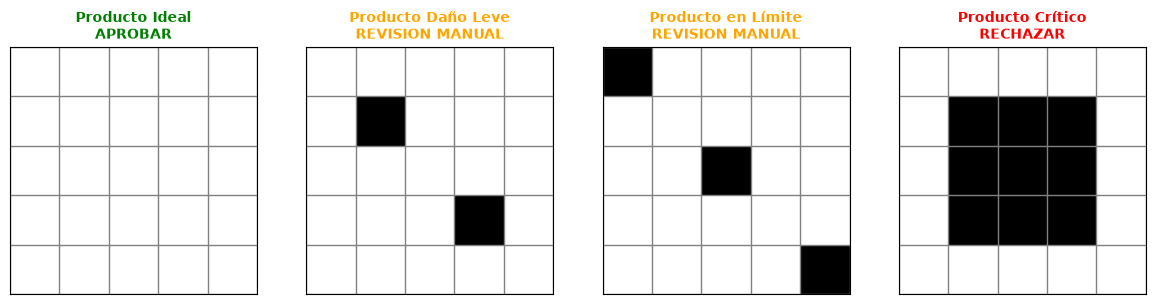

In [6]:
# 1. Producto perfecto (0 defectos)
matriz_optima = np.zeros((5, 5), dtype=int)

# 2. Producto con daño leve (2 defectos)
matriz_leve = np.zeros((5, 5), dtype=int)
matriz_leve[1, 1] = 1
matriz_leve[3, 3] = 1

# 3. Producto en el límite (3 defectos - entra a revisión)
matriz_borde = np.zeros((5, 5), dtype=int)
matriz_borde[0, 0] = 1
matriz_borde[2, 2] = 1
matriz_borde[4, 4] = 1

# 4. Producto muy dañado (9 defectos - rechazo directo)
matriz_critica = np.zeros((5, 5), dtype=int)
matriz_critica[1:4, 1:4] = 1 # Bloque central defectuoso

casos_prueba = [
    ("Producto Ideal", matriz_optima),
    ("Producto Daño Leve", matriz_leve),
    ("Producto en Límite", matriz_borde),
    ("Producto Crítico", matriz_critica)
]

print("--- SIMULACIÓN DE INSPECCIÓN VISUAL ---\n")

# Configurar el gráfico opcional pedido por la docente
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, (nombre, matriz) in enumerate(casos_prueba):
    accion, motivo = agente_inspeccion(matriz)
    
    # Imprimir en consola
    print(f"--- {nombre} ---")
    print(f"-> ACCIÓN: {accion.upper()}")
    print(f"-> MOTIVO: {motivo}\n")
    
    # Graficar la imagen (0 es negro, 1 es blanco en cmap gray_r para resaltar el defecto en negro)
    ax = axes[i]
    # Usamos gray_r para que el fondo (0) sea blanco y el defecto (1) sea oscuro/negro
    # CORRECCIÓN: Quitamos el edgecolor que causaba el error
    ax.imshow(matriz, cmap="gray_r", vmin=0, vmax=1) 
    
    # Cuadrícula para que se vean los 5x5 píxeles
    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
    # Título de cada subtrama
    color_titulo = 'green' if accion == 'aprobar' else ('orange' if accion == 'revision manual' else 'red')
    ax.set_title(f"{nombre}\n{accion.upper()}", color=color_titulo, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()